In [59]:
#1. Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report)

import joblib

In [61]:
#2. Load Dataset
df = pd.read_csv("churn.csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [63]:
#3. Basic Data Exploration
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

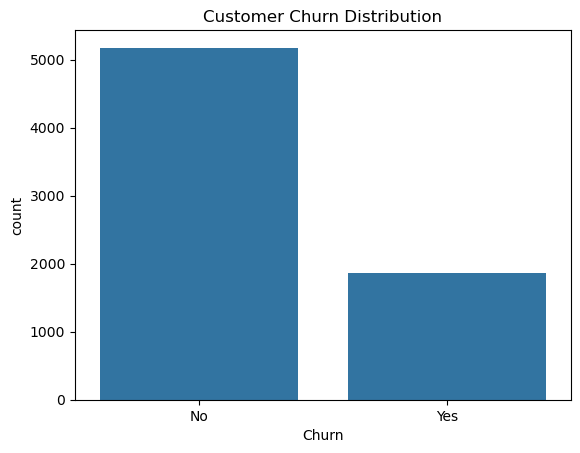

In [65]:
#4. Check Target Distribution
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

In [67]:
#5. Handle TotalCharges Column
#Convert to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [69]:
#Check null values
print(df["TotalCharges"].isnull().sum())

11


In [73]:
#Fill missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_14968\1458562851.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)


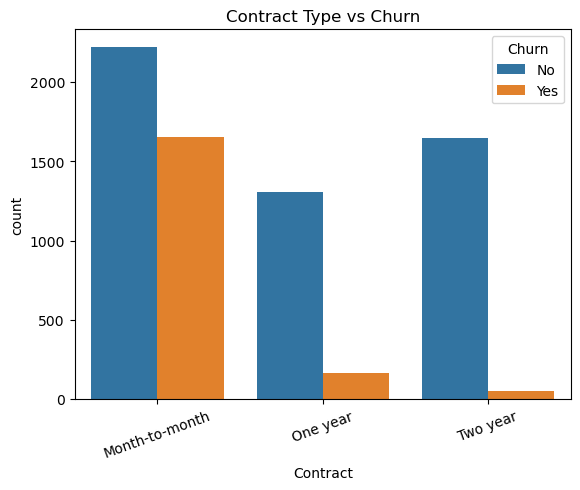

In [75]:
#6. Exploratory Data Analysis
#Contract Type vs Churn
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)

plt.show()

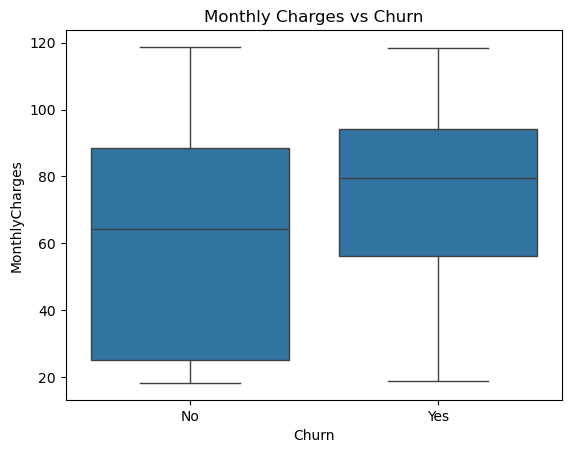

In [77]:
#Monthly Charges vs Churn
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

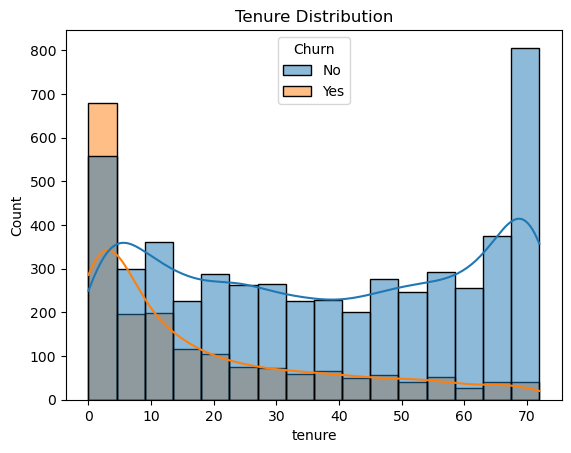

In [79]:
#Tenure Distribution
sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    kde=True
)

plt.title("Tenure Distribution")

plt.show()

In [81]:
#7. Encode Target Variable
le = LabelEncoder()
df["Churn"] = le.fit_transform(df["Churn"])

In [83]:
#8. Drop Customer ID
df.drop("customerID", axis=1, inplace=True)

In [85]:
#9. Convert Categorical Features
df = pd.get_dummies(
    df,
    drop_first=True)

In [87]:
print(df.shape)

(7043, 31)


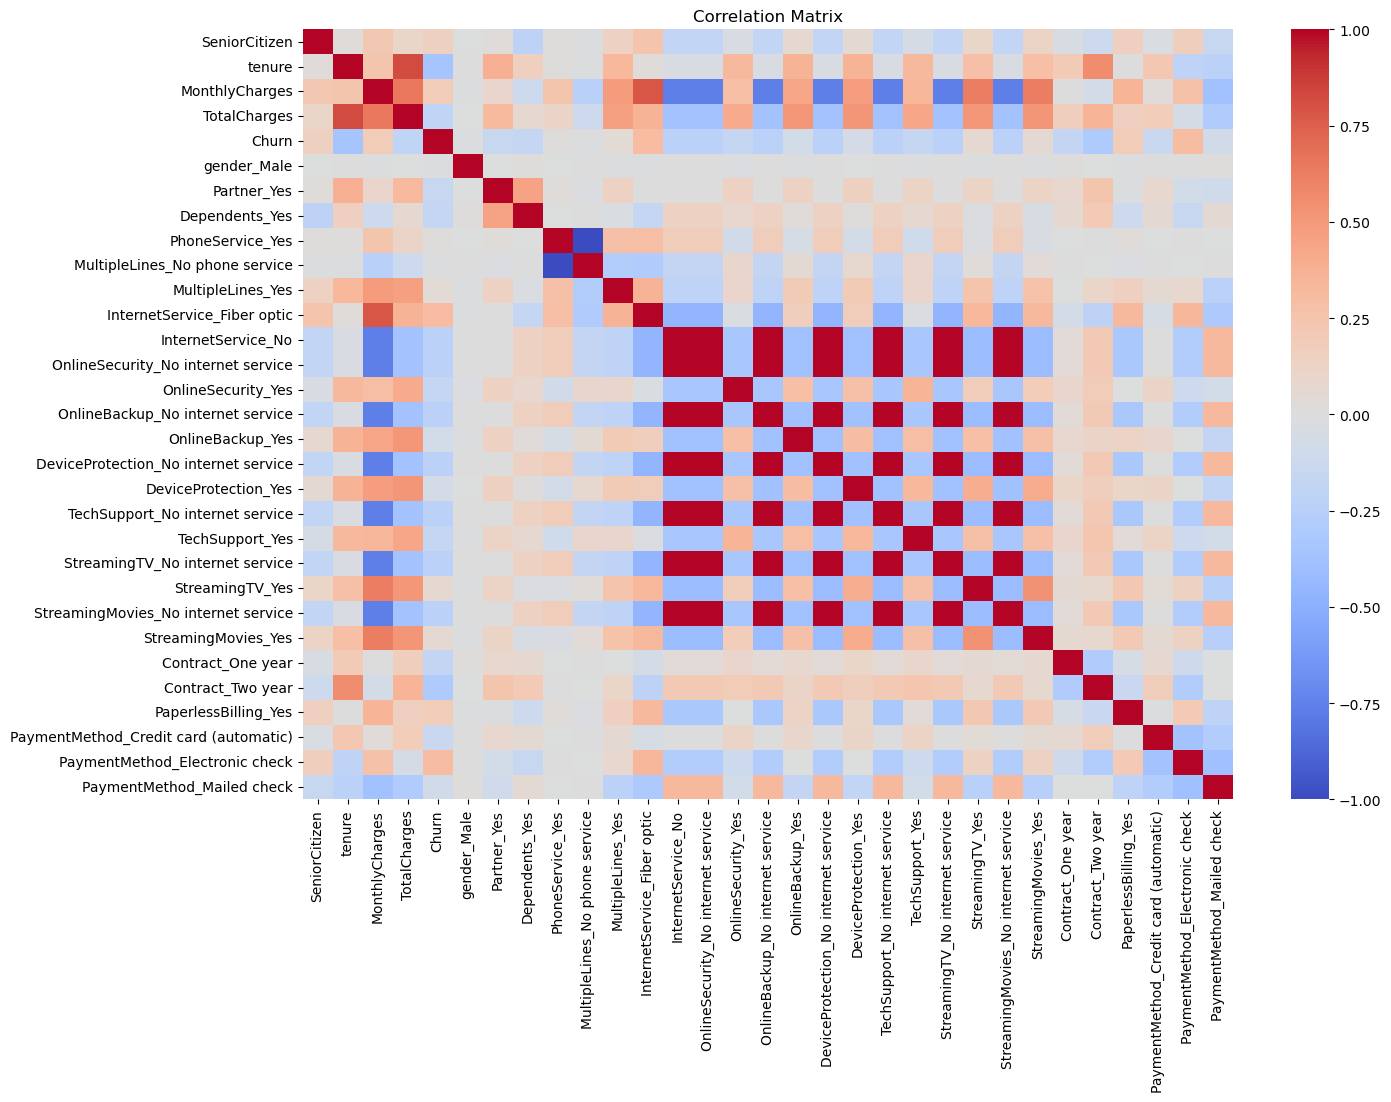

In [89]:
#10. Correlation Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

In [91]:
#11. Create Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [93]:
#12. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [95]:
#13. Train Logistic Regression
lr = LogisticRegression(
    max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(
    y_test,
    lr_pred
)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.8048261178140526


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [97]:
#14. Train Decision Tree
dt = DecisionTreeClassifier(
    random_state=42)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(
    y_test,
    dt_pred)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.7416607523066004


In [99]:
#15. Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(
    y_test,
    rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7863733144073811


In [101]:
#16. Compare Models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_acc,
        dt_acc,
        rf_acc
    ]
})
print(results)

                 Model  Accuracy
0  Logistic Regression  0.804826
1        Decision Tree  0.741661
2        Random Forest  0.786373


In [103]:
#17. Best Model Evaluation
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



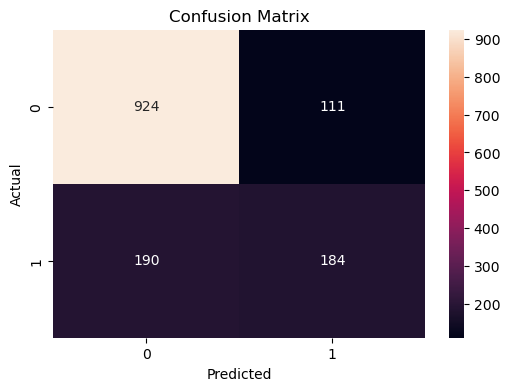

In [105]:
#18. Confusion Matrix
cm = confusion_matrix(
    y_test,
    rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [107]:
#19. Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
#Sort:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
print(importance.head(10))

                           Feature  Importance
3                     TotalCharges    0.192096
1                           tenure    0.174733
2                   MonthlyCharges    0.168413
28  PaymentMethod_Electronic check    0.038771
10     InternetService_Fiber optic    0.038641
25               Contract_Two year    0.030176
4                      gender_Male    0.028321
13              OnlineSecurity_Yes    0.028191
26            PaperlessBilling_Yes    0.025617
5                      Partner_Yes    0.023326


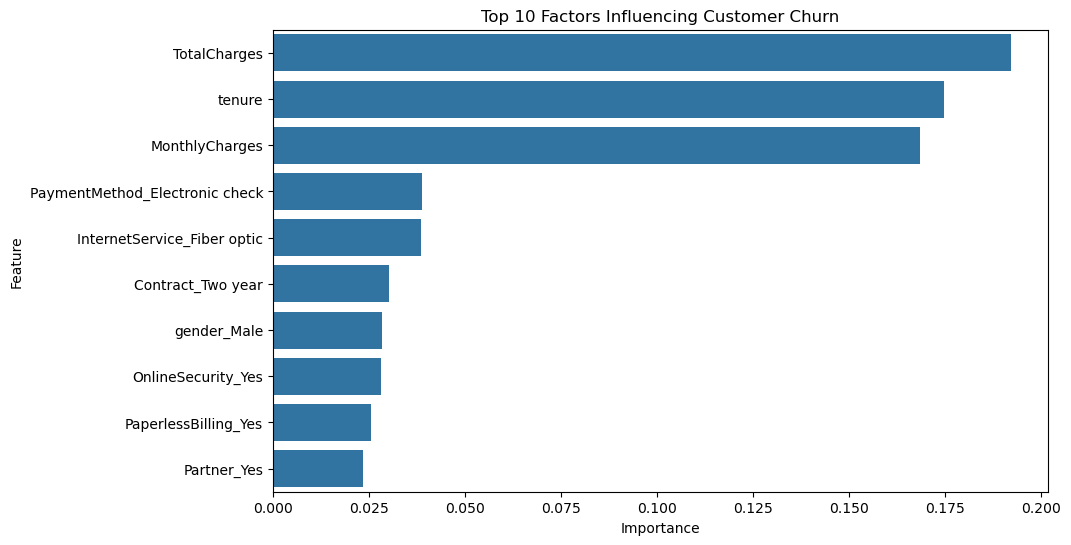

In [109]:
#20. Top 10 Important Features
top10 = importance.head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)
plt.title("Top 10 Factors Influencing Customer Churn")
plt.show()

In [111]:
#21. Save Best Model
joblib.dump(
    rf,
    "churn_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


Key Findings

1. Customers with month-to-month contracts show higher churn.

2. Customers with short tenure are more likely to leave.

3. Higher monthly charges increase churn probability.

4. Long-term contract customers are less likely to churn.

5. Contract type and tenure are among the strongest churn indicators.

Recommendations

1. Offer loyalty rewards to new customers.

2. Create retention campaigns for high-risk customers.

3. Encourage customers to switch to longer-term contracts.

4. Provide personalized offers to customers with high monthly charges.